# COMP4318 & 5318 - Machine Learning and Data Mining: Assignment 1

# 1. Summary

In this assignment, you are tasked with the challenge of developing machine learning (ML) classifiers capable of categorizing grayscale images into predefined classes. Your task involves employing various classification algorithms to identify which is most effective and efficient in processing image data. Additionally, you are required to document your methodologies and findings in a detailed report. The total score for this assignment is allocated as follows:

1. Code: max 65 points
2. Report: max 35 points

Detailed about assignment specifcations and scoring criteria can be found in the assignment page on Canvas (Assignments $\rightarrow$ Assignment 1 - Specification). The sections below provide comprehensive information on the assignment tasks and guidelines for submission.

Your code must be easily readable and well commented. The following are expected to be satisfied:

- **Readability & Consistency**: Easy to read, and consistent in style
  
- **Coding Descriptions & Comments**: Descriptions and comments clarify meaning where needed
  
- **Robustness**: Handles erroneous or unexpected input 

It should follow the structure below.

# 2. Dataset description

The dataset for this assignment is derived from the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist), a collection of fashion articles represented as grayscale images. This dataset can be downloaded from Canvas. The dataset consists of a training set of 30,000 examples and a test set of 5,000 examples. They belong to 10 different categories. The validation set is not provided, but you can randomly pick a subset of the training set for validation. Your prediction over the test set must be submitted to Kaggle to receive the public accuracy over first 2,000 examples, you will use this accuracy to analyse the performance of your proposed method. It is NOT allowed to use any examples from the test set for training; or it will be considered as cheating. The rest 3,000 labels of the test set are reserved for marking purpose.

Data samples are categorized into the following ten classes:

- 0: T-shirt/Top
- 1: Trouser
- 2: Pullover
- 3: Dress
- 4: Coat
- 5: Sandal
- 6: Shirt
- 7: Sneaker
- 8: Bag
- 9: Ankle boot

<img src="https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm" alt="DataSet" title="DataSet" width=500/>

The dataset can be downloaded from the Assignment 1 page on Canvas. Note that only a subset of the original Fashion-MNIST dataset is provided for this assignment. You must use the specific files supplied in the assignment materials for training and testing.

# 3. Data Preparation

The required `data` files are in the data folder, downloadable as a zip from the Assignment 1 - Specification page on Canvas. Extract the files into your working directory. The folder includes:

- `train.csv`: 30,000 labeled samples for training, evaluation, and model selection.
- `test1.csv`: 2,000 labeled samples for model efficiency testing (Canvas submission).
- `test2.csv`: 5,000 unlabeled samples for Kaggle evaluation.
- `sample.csv`: A sample prediction file format for Kaggle submission (`test_output.csv`).

Use Python's pandas library to load these CSV files into DataFrames, ensuring they are under the `./data/` directory.

## 3.1 Loading data

Use the following Python code to load the training data:  

In [12]:
import pandas as pd
import os
print(os.listdir("./data"))
pd.set_option('display.max_columns', 10)

['knn_outcome.csv', 'sample.csv', 'svm_outcome.csv', 'test1.csv', 'test2.csv', 'train.csv', 'tree_outcome.csv']


In [14]:
# train.csv including feature and label using for training model.
data_train_df = pd.read_csv('./data/train.csv') 

In [16]:
# print out the first 5 rows of the training dataframe
data_train_df.head()

,id,v1,v2,v3,v4,...,v781,v782,v783,v784,label
0,1,0,0,0,0,...,0,0,0,0,6
1,2,0,0,0,0,...,0,0,0,0,7
2,3,0,0,0,0,...,0,0,0,0,4
3,4,0,0,0,0,...,0,0,0,0,7
4,5,0,0,0,0,...,0,0,0,0,3


Then data would be a dataframe with 30,000 samples including 784 features (from v1 to v784) and its label.

In [19]:
# Selecting input feature
data_train_feature = data_train_df.loc[:, "v1":"v784"].to_numpy()

# Selecting output lable 
data_train_label = data_train_df.label.to_numpy()

Showing a sample data. The first example belongs to class 2: Pullover

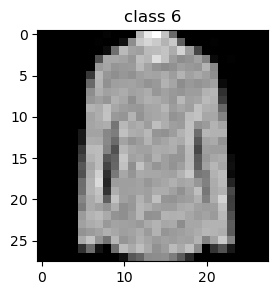

In [22]:
import matplotlib.pyplot as plt
data_train_feature = data_train_feature.reshape((data_train_feature.shape[0], 28, 28))
plt.figure(figsize=(3,3))
plt.imshow(data_train_feature[0], cmap=plt.get_cmap('gray'))
plt.title("class " + str(data_train_label[0]))
plt.show()

# 4. Task Description

## 4.1 Code

You will now explore and build diffferent ML models for the given dataset. You are required to implement at least **FOUR** models, which should include THREE from the following methods:

1. Nearest Neighbor
2. Logistic Regression
3. Naïve Bayes 
4. Decision Tree
5. SVM

and ONE of these ensemble methods:
    
 1. Bagging
 2. Boosting
 3. Random forest
    

For these implementations, you may use established packages and libraries that have been introduced in the tutorials such as sklearn or create your own custom solutions from scratch.

Your code must be easily readable and well commented. The following are expected to be satisfied:

- **Readability & Consistency**: Easy to read, and consistent in style
  
- **Coding Descriptions & Comments**: Descriptions and comments clarify meaning where needed
  
- **Robustness**: Handles erroneous or unexpected input 

It should follow the structure below.

### 4.1.1 Environment Setup

Install and import necessary packages and libraries used in your coding environment. It is recommended to specify their versions to ensure reproducibility.

In [33]:
from IPython.display import set_matplotlib_formats, display
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
#for accuracy_score, classification_report and confusion_matrix
from sklearn import metrics
from sklearn.model_selection import cross_val_score
%matplotlib inline

Define any necessary utility or helper functions (e.g., for plotting, optimization, etc.) if applicable.

### 4.1.2 Data Preprocessing

Implement at least ONE preprocessing technique on the dataset before model training. Possible methods include **Normalization**, **Dimensionality Reduction**, etc.

In [38]:
# read training data and testing data
train_data = pd.read_csv("./data/train.csv")
test_data =  pd.read_csv("./data/test1.csv")
X = train_data.loc[:,"v1":"v784"]
y = train_data.loc[:,"label"]
X_test = test_data.loc[:,"v1":"v784"]
y_test = test_data.loc[:,"label"]
# Split into 90% training set and 10% validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
print("X_train:",X_train.shape)
print("X_val:",X_val.shape)

X_train: (27000, 784)
X_val: (3000, 784)


In [40]:
# Normalise data
#creating an object ，calculate min and max value of the training data
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_val_norm = scaler.transform(X_val)
#to the training and test set, based on the min and max values of the training set:
X_test_norm = scaler.transform(X_test) 

### 4.1.3 Nearest Neighbor model

First test the accuracy using a basic model, then use GridSearchCV to find the best parameters

In [44]:
knn = KNeighborsClassifier(n_neighbors=3,p=1)
knn.fit(X_train_norm, y_train)
y_pred = knn.predict(X_val_norm)
print("Accuracy on test set: {:.2f}".format(knn.score(X_val_norm, y_val)))
print("Accuracy on test set: {:.2f}".format(accuracy_score(y_pred, y_val)))

Accuracy on test set: 0.85
Accuracy on test set: 0.85


#### Hyper-parameters Tuning

In [46]:
knn = KNeighborsClassifier()

param_grid = { 'n_neighbors': [2,3,5,7,9,11,13],
              'p':[1,2]}
print("Parameter grid:\n{}".format(param_grid))

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=10, return_train_score=True,n_jobs = 1,verbose=1)

grid_search.fit(X_train_norm, y_train)

best_knn_model = grid_search.best_estimator_
y_pred = best_knn_model.predict(X_val_norm)
accuracy = accuracy_score(y_val, y_pred)
print("Validation Set Accuracy:", accuracy)
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Parameter grid:
{'n_neighbors': [2, 3, 5, 7, 9, 11, 13], 'p': [1, 2]}
Fitting 10 folds for each of 14 candidates, totalling 140 fits
Validation Set Accuracy: 0.855
Best parameters: {'n_neighbors': 5, 'p': 1}
Best cross-validation score: 0.85
Best estimator:
KNeighborsClassifier(p=1)


#### Test the accuracy on test1 under the best signal KNN model

In [49]:
y_test_predect = best_knn_model.predict(X_test_norm)
accuracy = accuracy_score(y_test,y_test_predect)
print(accuracy)

0.8585


#### Plot the confusion matrix and performance metrics

In [51]:
# calculate other performance measures - F1, precision and recall 
#print(nb)
actual = y_test
predicted = best_knn_model.predict(X_test_norm)
print(metrics.classification_report(actual, predicted))

# show the confusion matrix
print(metrics.confusion_matrix(actual, predicted))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       191
           1       0.98      0.96      0.97       199
           2       0.71      0.79      0.75       191
           3       0.87      0.86      0.87       174
           4       0.78      0.81      0.80       203
           5       0.98      0.85      0.91       210
           6       0.72      0.59      0.65       201
           7       0.85      0.97      0.91       212
           8       0.98      0.93      0.95       216
           9       0.92      0.94      0.93       203

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

[[170   1   2   6   0   1  10   0   1   0]
 [  1 191   2   4   0   0   1   0   0   0]
 [  2   0 150   3  20   0  16   0   0   0]
 [  7   3   2 150   8   0   4   0   0   0]
 [  3   0  20   5 164   0  11   0   0   0]
 [  0   0   0   0   0 178 

### 4.1.4 SVM model

First, plot the principal component analysis (PCA) chart. Train three different SVM models with different kernels using both normalized data and PCA-processed data. Select the best model for the next step of hyperparameter tuning.

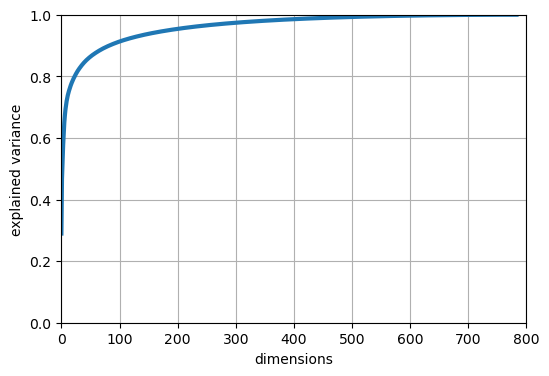

In [54]:
'''
Plot the images to determine the interval in which to test and select the best PCA.
'''
# Perform PCA without reducing dimensionality
pca = PCA()
pca.fit(X_train_norm)
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance vs number of dimensions

plt.figure(figsize = (6,4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 800, 0, 1])
plt.xlabel("dimensions")
plt.ylabel("explained variance")
plt.grid(True)
plt.show()

In [55]:
pca=PCA(n_components=184)
X_train_reduced = pca.fit_transform(X_train_norm)
X_val_reduced = pca.fit_transform(X_val_norm)
X_test_reduced = pca.fit_transform(X_test_norm)
print("Reduced shape of training data: {}".format(str(X_train_reduced.shape)))
print("Reduced shape of training data: {}".format(str(X_val_reduced.shape)))

Reduced shape of training data: (27000, 184)
Reduced shape of training data: (3000, 184)


#### Test the basic signal model SVM using both normal data and PCA-processed data separately

In [57]:
from sklearn.svm import SVC
# Test with normal data

# SVM with linear kernel 
lin_svm_norm = SVC(kernel="linear")
lin_svm_norm.fit(X_train_norm, y_train)
y_pred = lin_svm_norm.predict(X_val_norm)
print("Linear SVM - accuracy on test set: {:.3f}".format(accuracy_score(y_val, y_pred)))

# SVM with polynomial kernel
poly_svm_norm = SVC(kernel="poly", degree=2)#polynomial kernel with degree 2
poly_svm_norm.fit(X_train_norm, y_train)
y_pred = poly_svm_norm.predict(X_val_norm)
print("SVM with polynomial kernel - accuracy on test set: {:.3f}".format(accuracy_score(y_val, y_pred)))

# SVM with RBF kernel
rbf_svm_norm = SVC(kernel="rbf", gamma="auto")
rbf_svm_norm.fit(X_train_norm, y_train)
y_pred = rbf_svm_norm.predict(X_val_norm)
print("SVM with RBF kernel - accuracy on test set: {:.3f}".format(accuracy_score(y_val, y_pred)))

Linear SVM - accuracy on test set: 0.853
SVM with polynomial kernel - accuracy on test set: 0.870
SVM with RBF kernel - accuracy on test set: 0.852


In [58]:
# Test with PCA data

# SVM with linear kernel
lin_svm_pca = SVC(kernel="linear")
lin_svm_pca.fit(X_train_reduced, y_train)
y_pred = lin_svm_pca.predict(X_val_reduced)
print("Linear SVM - accuracy on test set: {:.3f}".format(accuracy_score(y_val, y_pred)))

# SVM with polynomial kernel
poly_svm_pca = SVC(kernel="poly", degree=2)#polynomial kernel with degree 2
poly_svm_pca.fit(X_train_reduced, y_train)
y_pred = poly_svm_pca.predict(X_val_reduced)
print("SVM with polynomial kernel - accuracy on test set: {:.3f}".format(accuracy_score(y_val, y_pred)))

# SVM with RBF kernel
rbf_svm_pca = SVC(kernel="rbf", gamma="auto")
rbf_svm_pca.fit(X_train_reduced, y_train)
y_pred = rbf_svm_pca.predict(X_val_reduced)
print("SVM with RBF kernel - accuracy on test set: {:.3f}".format(accuracy_score(y_val, y_pred)))

Linear SVM - accuracy on test set: 0.528
SVM with polynomial kernel - accuracy on test set: 0.648
SVM with RBF kernel - accuracy on test set: 0.694


#### Notice that the accuracy with PCA data is very low, possibly because the attributes of the images are related and discarding seemingly useless attributes is not ideal. Therefore, use the best polynomial kernel SVM model from the basic models, and then find the optimal hyperparameters.

In [60]:
# Parameter grid, tune hyperparameters C, degree, gamma

param_grid = {
   'C': [0.01, 0.1, 1, 10, 100],
   'degree': [2, 3, 4],
   'gamma': ['scale', 'auto', 0.1, 1]
}
print("Parameter grid:\n{}".format(param_grid))


# Use GridSearchCV for hyperparameter search
grid_search = GridSearchCV(
    poly_svm_norm, param_grid, cv=4, return_train_score=True, n_jobs=1, verbose=3
)

# Train the model and perform grid search
grid_search.fit(X_train_norm, y_train)

# Evaluate model performance on the validation set.
test_score = grid_search.score(X_val_norm, y_val)
print(f" Validition set score: {test_score:.4f}")

# Output the best hyperparameters and cross-validation scores
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Obtain the best model after GridSearchCV tuning
best_model_svm = grid_search.best_estimator_
print(f"Best estimator:\n{grid_search.best_estimator_}")
# Use the best model to make predictions on the test set.
y_pred_test = best_model_svm.predict(X_test_norm)
# Calculate accuracy on the test set
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Best Model - Accuracy on Test Set: {accuracy:.4f}")
# Output the best model.
print(f"Best Estimator: {best_model_svm}")
print(f"Best parameters: {grid_search.best_params_}")

Parameter grid:
{'C': [0.01, 0.1, 1, 10, 100], 'degree': [2, 3, 4], 'gamma': ['scale', 'auto', 0.1, 1]}
Fitting 4 folds for each of 60 candidates, totalling 240 fits
[CV 1/4] END C=0.01, degree=2, gamma=scale;, score=(train=0.721, test=0.715) total time=  55.5s
[CV 2/4] END C=0.01, degree=2, gamma=scale;, score=(train=0.718, test=0.718) total time=  55.4s
[CV 3/4] END C=0.01, degree=2, gamma=scale;, score=(train=0.718, test=0.717) total time=  55.5s
[CV 4/4] END C=0.01, degree=2, gamma=scale;, score=(train=0.720, test=0.714) total time=  55.3s
[CV 1/4] END C=0.01, degree=2, gamma=auto;, score=(train=0.202, test=0.200) total time= 2.2min
[CV 2/4] END C=0.01, degree=2, gamma=auto;, score=(train=0.192, test=0.192) total time= 2.2min
[CV 3/4] END C=0.01, degree=2, gamma=auto;, score=(train=0.194, test=0.189) total time= 2.2min
[CV 4/4] END C=0.01, degree=2, gamma=auto;, score=(train=0.197, test=0.201) total time= 2.2min
[CV 1/4] END C=0.01, degree=2, gamma=0.1;, score=(train=0.890, test=0.

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       191
           1       0.97      0.99      0.98       199
           2       0.82      0.85      0.84       191
           3       0.90      0.90      0.90       174
           4       0.86      0.86      0.86       203
           5       0.95      0.93      0.94       210
           6       0.77      0.69      0.73       201
           7       0.92      0.93      0.92       212
           8       0.99      0.95      0.97       216
           9       0.92      0.95      0.93       203

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

[[167   0   2   5   0   1  16   0   0   0]
 [  0 197   0   2   0   0   0   0   0   0]
 [  5   0 163   2  14   1   5   0   1   0]
 [  1   6   1 157   5   0   4   0   0   0]
 [  2   0  12   4 174   0  11   0   0   0]
 [  0   0   0   0   0 195 

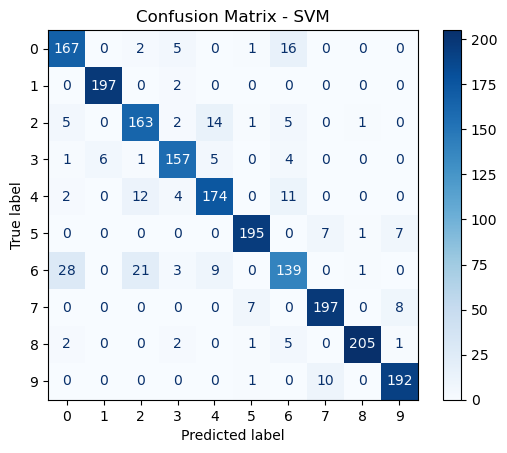

In [91]:
# calculate other performance measures - F1, precision and recall 
#print(nb)
actual = y_test
predicted = best_model_svm.predict(X_test_norm)
print(metrics.classification_report(actual, predicted))

# show the confusion matrix
print(metrics.confusion_matrix(actual, predicted))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - SVM')
plt.show()

### 4.1.5 Decision Tree model

In [62]:
# Basic Model
# Define the decision tree model.
tree_clf = DecisionTreeClassifier(criterion='entropy', max_depth=5,random_state=42)

tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_val)

# Calculate accuracy on the validation set
accuracy = accuracy_score(y_val, y_pred_tree)
print(f"Decision Tree - accuracy on val set: {accuracy:.2f}")

Decision Tree - accuracy on val set: 0.73


#### find the optimal hyperparameters

In [64]:
# Parameter grid, tune hyperparameters ： max_depth，criterion，min_samples_split，min_samples_leaf

'''
Here's the translation for the parameters:

max_depth: The maximum depth of the decision tree, which refers to the longest path from the root to a leaf. It controls the complexity of the tree.
  
criterion: The criterion for evaluating the split quality.
  gini: Gini impurity, measures the purity of the samples in a node; lower values are better.
  entropy: Information entropy, measures the level of disorder or uncertainty; features are chosen to minimize entropy during splits.

min_samples_split: The minimum number of samples required to split an internal node.

min_samples_leaf: The minimum number of samples required to be at a leaf node.
'''

param_grid = {
    'max_depth': [5,10,15,20],
    'min_samples_split': [5,10,15,20],
    'min_samples_leaf': [1,3,5,7,9],
    'criterion': ['gini', 'entropy']
}


grid_search = GridSearchCV(estimator=tree_clf, param_grid=param_grid, cv=10, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

# Output the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Use the best model to make predictions on the validation set
best_tree_clf = grid_search.best_estimator_
y_pred_tree_best = best_tree_clf.predict(X_val)

# Calculate accuracy on the validation set.
accuracy = accuracy_score(y_val, y_pred_tree_best)
print(f"Best Decision Tree - accuracy on val set: {accuracy:.2f}")

# Use the best model to make predictions on the test1 set
y_pred_tree = best_tree_clf.predict(X_test)

# Calculate accuracy on the test1 set.
accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree - accuracy on test set: {accuracy:.2f}")


Fitting 10 folds for each of 160 candidates, totalling 1600 fits
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best Decision Tree - accuracy on val set: 0.81
Decision Tree - accuracy on test set: 0.81


              precision    recall  f1-score   support

           0       0.75      0.77      0.76       295
           1       0.96      0.92      0.94       300
           2       0.70      0.74      0.72       298
           3       0.81      0.83      0.82       312
           4       0.69      0.72      0.70       292
           5       0.91      0.85      0.88       299
           6       0.59      0.55      0.57       294
           7       0.84      0.93      0.88       287
           8       0.94      0.91      0.92       324
           9       0.94      0.90      0.92       299

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000

[[228   1   7  10   3   0  43   0   3   0]
 [  4 276   1  13   1   0   5   0   0   0]
 [  5   1 220   7  38   0  26   0   1   0]
 [ 12   6   1 259  23   1  10   0   0   0]
 [  3   2  42  11 210   0  22   0   2   0]
 [  0   0   0   3   1 253 

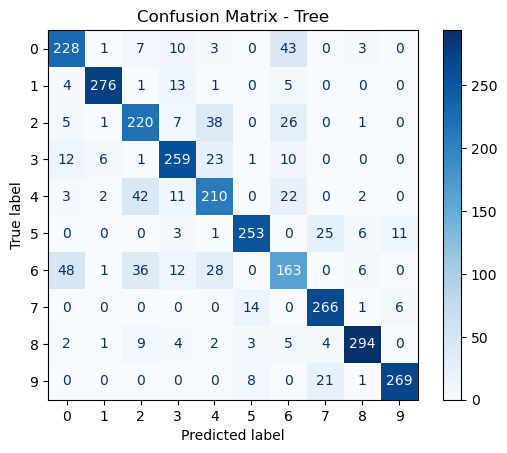

In [65]:
# calculate other performance measures - F1, precision and recall 
#print(nb)
actual = y_val
predicted = best_tree_clf.predict(X_val)
print(metrics.classification_report(actual, predicted))

# show the confusion matrix
print(metrics.confusion_matrix(actual, predicted))

# Confusion Matrix Visualization
cm = confusion_matrix(y_val, predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Tree')
plt.show()

### The SVM model has the highest accuracy at 0.8930. Since it performs the best, I will use it to train a bagging ensemble model. Bagging combines several models to make predictions, which can help improve accuracy and make the model more reliable.

### 4.1.6 Bagging ensemble model

In [68]:
# Use Bagging with the best SVM model.
bagging_clf = BaggingClassifier(
    estimator=best_model_svm,  # Use the best model as the base learner
    n_estimators=500,  # Number of base learners (sub-learners)
    max_samples=0.8,  # Each sub-learner uses 80% of the samples
    bootstrap=True,  # Use sampling with replacement
    n_jobs=-1,  
    random_state=42
)

# Train the Bagging model.
bagging_clf.fit(X_train_norm, y_train)

#。Make predictions on the validation set.
y_pred_bagging = bagging_clf.predict(X_val_norm)

# Calculate the accuracy.
accuracy_bagging = accuracy_score(y_val, y_pred_bagging)
print(f"Bagging with Best Model - Accuracy on val Set: {accuracy_bagging:.4f}")

# Make predictions on the test set.
y_pred_bagging = bagging_clf.predict(X_test_norm)

# 计Calculate the accuracy.
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Bagging with Best Model - Accuracy on Test Set: {accuracy_bagging:.4f}")

Bagging with Best Model - Accuracy on val Set: 0.8843
Bagging with Best Model - Accuracy on Test Set: 0.8935


              precision    recall  f1-score   support

           0       0.84      0.88      0.86       191
           1       0.97      0.99      0.98       199
           2       0.81      0.84      0.83       191
           3       0.89      0.91      0.90       174
           4       0.88      0.85      0.86       203
           5       0.94      0.92      0.93       210
           6       0.78      0.71      0.74       201
           7       0.92      0.93      0.93       212
           8       0.98      0.94      0.96       216
           9       0.91      0.94      0.93       203

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

[[168   0   1   5   0   1  14   0   1   1]
 [  0 197   0   2   0   0   0   0   0   0]
 [  5   0 161   2  15   1   6   0   1   0]
 [  2   6   2 158   3   0   3   0   0   0]
 [  2   0  11   5 173   0  12   0   0   0]
 [  0   0   0   0   0 194 

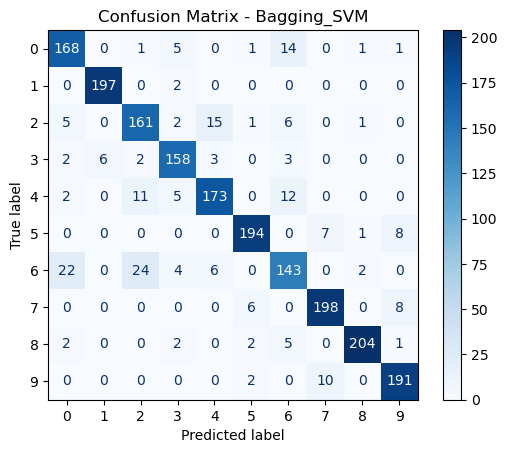

In [89]:
# calculate other performance measures - F1, precision and recall 
actual = y_test
predicted = bagging_clf.predict(X_test_norm)
print(metrics.classification_report(actual, predicted))

# show the confusion matrix
print(metrics.confusion_matrix(actual, predicted))

# Confusion Matrix Visualization
cm = confusion_matrix(actual, predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Bagging_SVM')
plt.show()

### 4.1.7 Evaluation

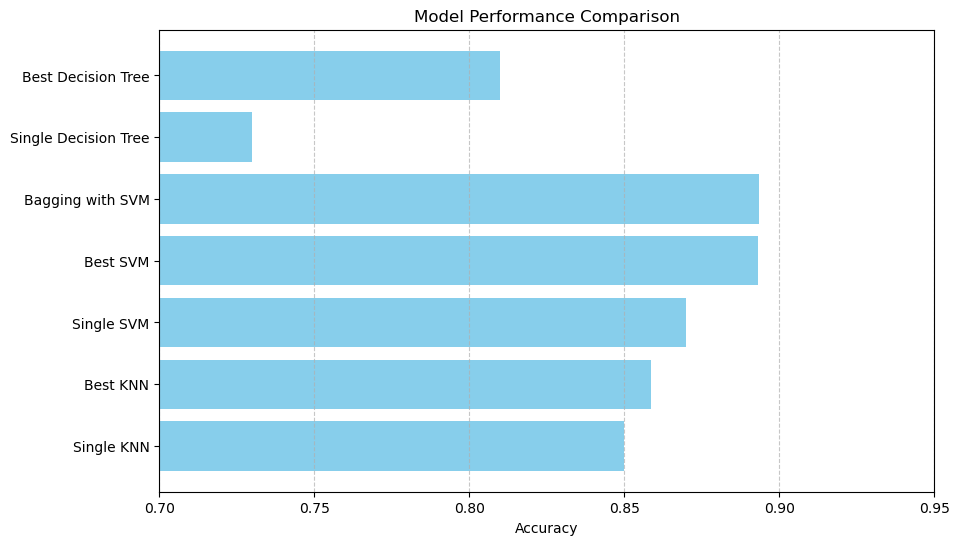

In [71]:
import matplotlib.pyplot as plt
# Model names and their accuracies
models = ['Single KNN', 'Best KNN', 'Single SVM', 'Best SVM', 'Bagging with SVM','Single Decision Tree', 'Best Decision Tree']
accuracies = [0.85, 0.8585, 0.870, 0.8930,0.8935, 0.73, 0.81]

# Create the histogram
plt.figure(figsize=(10, 6))
plt.barh(models, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xlim(0.7, 0.95)  # Set limits for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

From the chart, it can be seen that the SVM model has the highest accuracy, and tuning the parameters for the decision tree yields the most significant improvement in accuracy.

### 4.1.8 Comparison

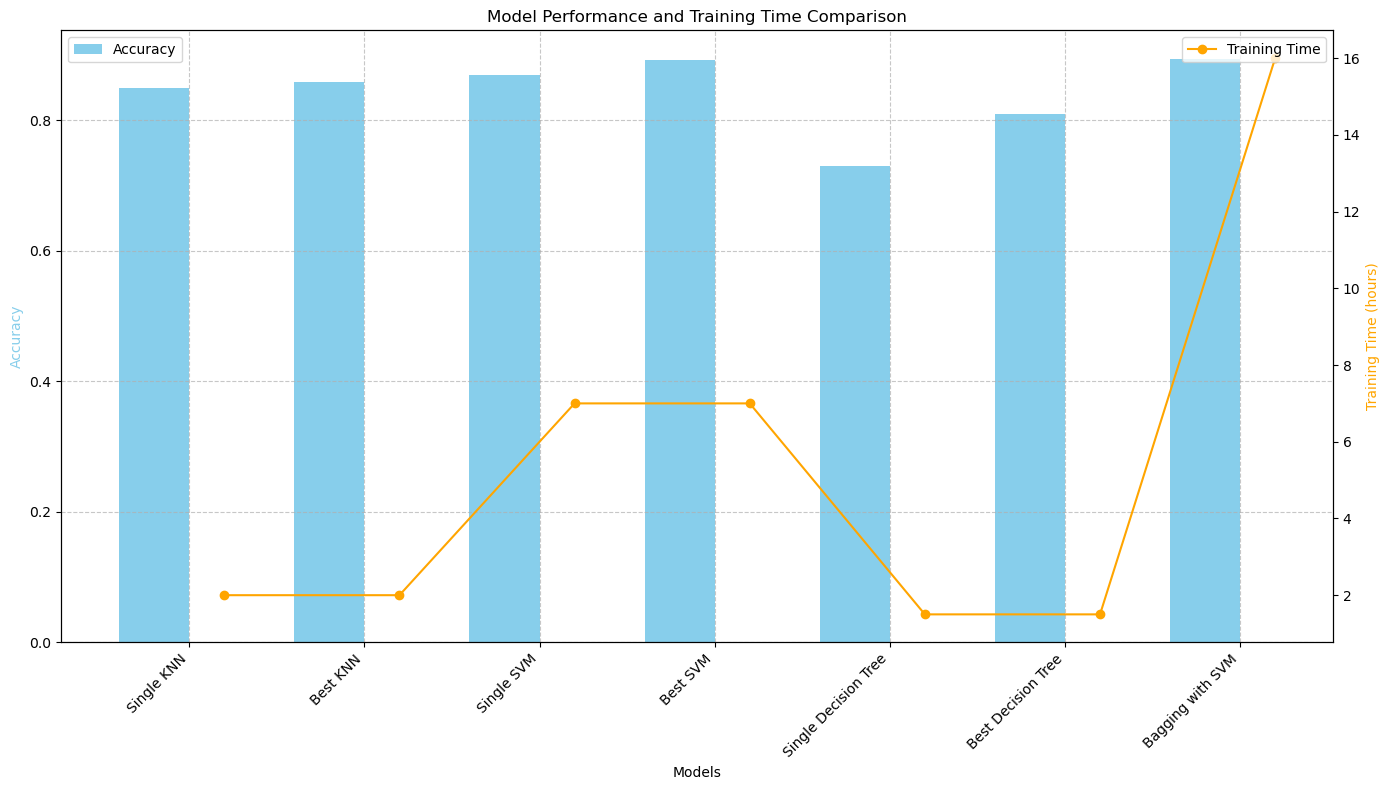

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Single KNN', 'Best KNN', 'Single SVM', 'Best SVM', 'Single Decision Tree', 'Best Decision Tree', 'Bagging with SVM']
accuracies = [0.85, 0.8585, 0.870, 0.8930, 0.73, 0.81, 0.8935]
training_times = [2, 2, 7, 7, 1.5, 1.5, 16]  # in hours

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar width and positions
bar_width = 0.4
index = np.arange(len(models))

# Bars for accuracies
bars1 = ax1.bar(index - bar_width/2, accuracies, bar_width, label='Accuracy', color='skyblue')

# Secondary y-axis for training time
ax2 = ax1.twinx()
lines = ax2.plot(index + bar_width/2, training_times, 'o-', color='orange', label='Training Time')

# Labeling
ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy', color='skyblue')
ax2.set_ylabel('Training Time (hours)', color='orange')

# Ticks and labels
ax1.set_xticks(index)
ax1.set_xticklabels(models, rotation=45, ha='right')

# Add gridlines and title
ax1.grid(True, linestyle='--', alpha=0.7)
plt.title('Model Performance and Training Time Comparison')
fig.tight_layout()

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

###  4.1.9 The Best Classifier

SVM achieves the highest accuracy (0.893) with a training time of 7 hours, offering a good balance between performance and time.
Using Bagging with SVM slightly improves accuracy (0.8935), but the training time significantly increases to 16 hours, making it a less ideal result for the model. The trade-off between input and output is disproportionate.
Decision Tree may not perform as well as the SVM models, but its return on investment in terms of performance is more favorable.
KNN models offer good accuracy with moderate training times, making them a middle-ground option.
If training time is the top priority, KNN or Decision Tree would be better choices. However, if accuracy is the main focus, Best SVM or Bagging with SVM should be prioritized. The final decision depends on the specific requirements of the situation.
This provides a balanced approach, depending on whether you prioritize training time or accuracy for your project.

### 4.1.10 Loading testing data

In [78]:
# test2.csv includes 5000 samples used for label prediction. Test samples do not have labels.
data_test_df = pd.read_csv('./data/test2.csv', index_col=0)
# print out the first 5 rows of the test dataframe
data_test_df.head()

,v1,v2,v3,v4,v5,...,v780,v781,v782,v783,v784
id,,,,,,,,,,,
1,0,0,0,0,0,...,0,0,0,0,0
2,0,0,0,0,0,...,0,0,0,0,0
3,0,0,0,0,0,...,0,0,0,0,0
4,0,0,1,0,2,...,0,0,0,0,0
5,0,0,0,0,0,...,0,0,0,0,0


In [86]:
X_test2 = data_test_df.loc[:,"v1":"v784"]
X_test2 = scaler.transform(X_test2)
y_pre = bagging_clf.predict(X_test2)
test2_outcome = pd.DataFrame()
test2_outcome['lable'] = list(y_pre)
test2_outcome.to_csv(r"./data/test_outcome.csv")